# Baseline Clause Classifier — SVM
---
## Phase 1 — Load Dataset

In [1]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv(r"C:\Users\chari\Desktop\Contract_Intelligence_AI\data\processed\clause_classification_dataset.csv")

print("=" * 60)
print("DATASET LOADED SUCCESSFULLY")
print("=" * 60)

DATASET LOADED SUCCESSFULLY


### 1.1 — Inspect Shape

In [2]:
print(f"Shape: {df.shape}")
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")
print(f"\nColumn Names: {df.columns.tolist()}")
print(f"\nData Types:\n{df.dtypes}")

Shape: (2040, 3)
Rows: 2040
Columns: 3

Column Names: ['text', 'label_name', 'target']

Data Types:
text          object
label_name    object
target         int64
dtype: object


### 1.2 — Inspect Labels

In [3]:
print("Label Distribution:\n")
print(df['label_name'].value_counts())
print(f"\nUnique Labels: {df['label_name'].nunique()}")
print(f"\nTarget Distribution:\n{df['target'].value_counts()}")
print(f"\nTarget Ratio (1s): {df['target'].mean():.2%}")

Label Distribution:

label_name
Renewal Term                   510
Termination For Convenience    510
Uncapped Liability             510
Cap On Liability               510
Name: count, dtype: int64

Unique Labels: 4

Target Distribution:
target
0    1295
1     745
Name: count, dtype: int64

Target Ratio (1s): 36.52%


### 1.3 — Check for Nulls

In [4]:
print("Null Values per Column:\n")
print(df.isnull().sum())
print(f"\nTotal Nulls: {df.isnull().sum().sum()}")

Null Values per Column:

text          0
label_name    0
target        0
dtype: int64

Total Nulls: 0


### 1.4 — Sample Rows

In [5]:
pd.set_option('display.max_colwidth', 100)
df.head(10)

,text,label_name,target
0,"nt shall be ten (10) years (the ""Term"") which shall commence on the date upon which the Company ...",Renewal Term,1
1,"wo, the expectation for year two will have been met, but there will be no carry-over to year thr...",Termination For Convenience,0
2,Appointment. The Company appoints the Distributor as an exclusive distributor of Products in the...,Uncapped Liability,0
3,"nder shall be free from defects in design, materials and workmanship for a period of twenty-four...",Cap On Liability,0
4,"ime the relevant liability is to be assessed (the ""Applicable Time""), it shall be calculated on ...",Renewal Term,0
5,ve Google a reasonable time to fix the problem and (if necessary) to supply Distributor with a c...,Termination For Convenience,0
6,"'s liability under Clause 10 (Indemnities), or Distributor's liability under Clause 2 (License G...",Uncapped Liability,1
7,"'s liability under Clause 10 (Indemnities), or Distributor's liability under Clause 2 (License G...",Cap On Liability,1
8,"is commissioned the buyer. 5. PACKING: To be packed in new strong wooden case(s) /carton(s), sui...",Renewal Term,0
9,"s forward amendments or not accept orders, the seller shall be in the form of a written notice t...",Termination For Convenience,0


### 1.5 — Text Length Analysis

In [6]:
df['text_length'] = df['text'].str.len()
print("Text Length Statistics (characters):")
print(df['text_length'].describe())

Text Length Statistics (characters):
count    2040.000000
mean      637.945588
std       253.577964
min       461.000000
25%       500.000000
50%       500.000000
75%       718.000000
max      3253.000000
Name: text_length, dtype: float64


---
## Phase 2 — Train/Test Split (80/20)

In [7]:
from sklearn.model_selection import train_test_split

X = df['text']
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("=" * 60)
print("TRAIN/TEST SPLIT COMPLETE")
print("=" * 60)
print(f"\nTraining set:  {X_train.shape[0]} samples ({X_train.shape[0]/len(X):.0%})")
print(f"Test set:      {X_test.shape[0]} samples ({X_test.shape[0]/len(X):.0%})")
print(f"\nTraining target distribution:\n{y_train.value_counts()}")
print(f"\nTest target distribution:\n{y_test.value_counts()}")

TRAIN/TEST SPLIT COMPLETE

Training set:  1632 samples (80%)
Test set:      408 samples (20%)

Training target distribution:
target
0    1036
1     596
Name: count, dtype: int64

Test target distribution:
target
0    259
1    149
Name: count, dtype: int64


---
## Phase 3 — TF-IDF Vectorization
Convert text to numerical features so the model can "see" text.

In [8]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1, 2),
    stop_words='english',
    min_df=2,
    max_df=0.95
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print("=" * 60)
print("TF-IDF VECTORIZATION COMPLETE")
print("=" * 60)
print(f"\nVocabulary Size: {len(tfidf.vocabulary_)}")
print(f"Training Matrix Shape: {X_train_tfidf.shape}")
print(f"Test Matrix Shape:     {X_test_tfidf.shape}")
print(f"\nTop 20 Features (by IDF):")
feature_names = tfidf.get_feature_names_out()
idf_scores = tfidf.idf_
top_idx = np.argsort(idf_scores)[:20]
for i in top_idx:
    fname = feature_names[i]
    print(f"  {fname:30s} IDF={idf_scores[i]:.4f}")


TF-IDF VECTORIZATION COMPLETE

Vocabulary Size: 10000
Training Matrix Shape: (1632, 10000)
Test Matrix Shape:     (408, 10000)

Top 20 Features (by IDF):
  agreement                      IDF=1.4107
  shall                          IDF=1.4638
  party                          IDF=1.8161
  parties                        IDF=2.3344
  section                        IDF=2.4475
  date                           IDF=2.4739
  notice                         IDF=2.5038
  including                      IDF=2.5261
  written                        IDF=2.5374
  termination                    IDF=2.5575
  term                           IDF=2.5811
  event                          IDF=2.6236
  provided                       IDF=2.6361
  prior                          IDF=2.6746
  liability                      IDF=2.6877
  agreement shall                IDF=2.7317
  damages                        IDF=2.7492
  days                           IDF=2.7634
  breach                         IDF=2.8072
  obligat

---
## Phase 4 — Train Baseline Model (Support Vector Machine)
Why SVM?
- Excellent performance on high-dimensional sparse data (like TF-IDF)
- Strong theoretical foundation with maximum margin classification
- Linear SVM is fast and highly effective for text classification
- Often outperforms Logistic Regression on NLP tasks

In [9]:
from sklearn.svm import LinearSVC

model = LinearSVC(
    max_iter=2000,
    random_state=42,
    C=1.0,
    loss='squared_hinge',
    dual='auto'
)

model.fit(X_train_tfidf, y_train)

print("=" * 60)
print("MODEL TRAINING COMPLETE")
print("=" * 60)
print(f"\nModel: {model.__class__.__name__}")
print(f"Loss: {model.loss}")
print(f"Max Iterations: {model.max_iter}")
print(f"Regularization (C): {model.C}")
print(f"\nTraining Accuracy: {model.score(X_train_tfidf, y_train):.4f}")

MODEL TRAINING COMPLETE

Model: LinearSVC
Loss: squared_hinge
Max Iterations: 2000
Regularization (C): 1.0

Training Accuracy: 0.9963


---
## Phase 5 — Evaluation
Key metrics: Accuracy, Precision, Recall, F1-score

**MOST IMPORTANT**: Recall + F1 — legal AI must NOT miss dangerous clauses.

In [10]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, classification_report, confusion_matrix,
    ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt

y_pred = model.predict(X_test_tfidf)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("=" * 60)
print("MODEL EVALUATION RESULTS")
print("=" * 60)
print(f"\n  Accuracy:   {accuracy:.4f}")
print(f"  Precision:  {precision:.4f}")
print(f"  Recall:     {recall:.4f}  <- CRITICAL for legal AI")
print(f"  F1-Score:   {f1:.4f}  <- CRITICAL for legal AI")

print("\n" + "=" * 60)
print("CLASSIFICATION REPORT")
print("=" * 60)
print(classification_report(y_test, y_pred, target_names=['Absent (0)', 'Present (1)']))

MODEL EVALUATION RESULTS

  Accuracy:   0.9387
  Precision:  0.9493
  Recall:     0.8792  <- CRITICAL for legal AI
  F1-Score:   0.9129  <- CRITICAL for legal AI

CLASSIFICATION REPORT
              precision    recall  f1-score   support

  Absent (0)       0.93      0.97      0.95       259
 Present (1)       0.95      0.88      0.91       149

    accuracy                           0.94       408
   macro avg       0.94      0.93      0.93       408
weighted avg       0.94      0.94      0.94       408



### 5.1 — Confusion Matrix

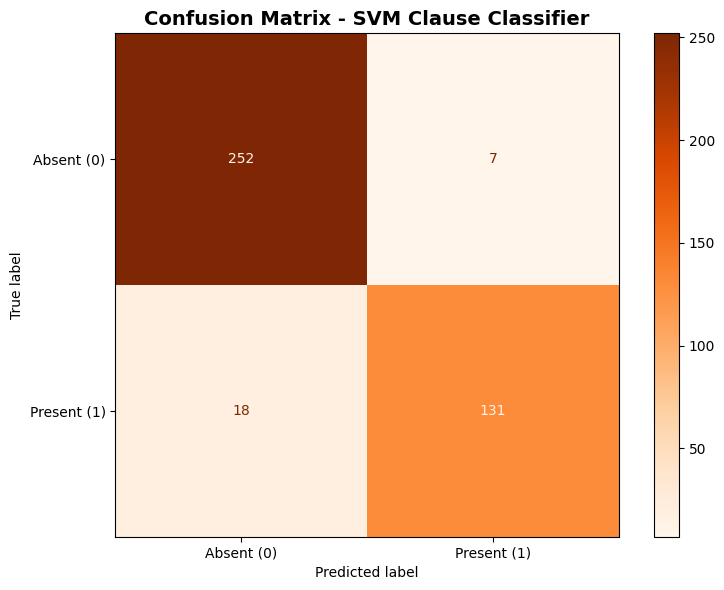


True Negatives:  252  (correctly identified as absent)
False Positives: 7  (incorrectly flagged as present)
False Negatives: 18  (MISSED dangerous clauses!) <- CRITICAL
True Positives:  131  (correctly identified as present)


In [11]:
fig, ax = plt.subplots(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Absent (0)', 'Present (1)'])
disp.plot(ax=ax, cmap='Oranges', values_format='d')
ax.set_title('Confusion Matrix - SVM Clause Classifier', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"\nTrue Negatives:  {tn}  (correctly identified as absent)")
print(f"False Positives: {fp}  (incorrectly flagged as present)")
print(f"False Negatives: {fn}  (MISSED dangerous clauses!) <- CRITICAL")
print(f"True Positives:  {tp}  (correctly identified as present)")

---
## Phase 6 — Analyze Results

### 6.1 — Per-Label Performance

In [12]:
label_names = df['label_name'].unique()
test_indices = X_test.index

print("=" * 60)
print("PER-LABEL PERFORMANCE BREAKDOWN")
print("=" * 60)

for label in sorted(label_names):
    mask = df.loc[test_indices, 'label_name'] == label
    if mask.sum() == 0:
        continue
    y_true_label = y_test[mask]
    y_pred_label = y_pred[mask.values]

    acc = accuracy_score(y_true_label, y_pred_label)

    if y_true_label.nunique() > 1:
        prec = precision_score(y_true_label, y_pred_label, zero_division=0)
        rec = recall_score(y_true_label, y_pred_label, zero_division=0)
        f1_l = f1_score(y_true_label, y_pred_label, zero_division=0)
    else:
        prec = rec = f1_l = float('nan')

    print(f"\n{label}")
    print(f"  Samples: {mask.sum()}")
    print(f"  Accuracy:  {acc:.4f}")
    print(f"  Precision: {prec:.4f}")
    print(f"  Recall:    {rec:.4f}")
    print(f"  F1-Score:  {f1_l:.4f}")

PER-LABEL PERFORMANCE BREAKDOWN

Cap On Liability
  Samples: 98
  Accuracy:  0.9286
  Precision: 1.0000
  Recall:    0.8627
  F1-Score:  0.9263

Renewal Term
  Samples: 108
  Accuracy:  0.9352
  Precision: 0.9375
  Recall:    0.8571
  F1-Score:  0.8955

Termination For Convenience
  Samples: 105
  Accuracy:  0.9048
  Precision: 0.8889
  Recall:    0.8421
  F1-Score:  0.8649

Uncapped Liability
  Samples: 97
  Accuracy:  0.9897
  Precision: 0.9615
  Recall:    1.0000
  F1-Score:  0.9804


### 6.2 — Class Imbalance Analysis

In [13]:
print("CLASS IMBALANCE ANALYSIS")
print("=" * 60)

total = len(df)
pos = (df['target'] == 1).sum()
neg = (df['target'] == 0).sum()
print(f"\nOverall Distribution:")
print(f"  Positive (clause present): {pos} ({pos/total:.1%})")
print(f"  Negative (clause absent):  {neg} ({neg/total:.1%})")
ratio_str = f"1:{neg/pos:.1f}" if pos > 0 else "N/A"
print(f"  Imbalance Ratio: {ratio_str}")

print(f"\nPer-Label Imbalance:")
for label in sorted(label_names):
    sub = df[df['label_name'] == label]
    p = (sub['target'] == 1).sum()
    n = (sub['target'] == 0).sum()
    r = f"1:{n/p:.1f}" if p > 0 else "N/A"
    print(f"  {label:35s}  pos={p:4d}  neg={n:4d}  ratio={r}")

CLASS IMBALANCE ANALYSIS

Overall Distribution:
  Positive (clause present): 745 (36.5%)
  Negative (clause absent):  1295 (63.5%)
  Imbalance Ratio: 1:1.7

Per-Label Imbalance:
  Cap On Liability                     pos= 275  neg= 235  ratio=1:0.9
  Renewal Term                         pos= 176  neg= 334  ratio=1:1.9
  Termination For Convenience          pos= 183  neg= 327  ratio=1:1.8
  Uncapped Liability                   pos= 111  neg= 399  ratio=1:3.6


### 6.3 — Error Analysis (False Positives & False Negatives)

In [14]:
test_df = df.loc[test_indices].copy()
test_df['predicted'] = y_pred
test_df['actual'] = y_test.values

false_negatives = test_df[(test_df['actual'] == 1) & (test_df['predicted'] == 0)]
false_positives = test_df[(test_df['actual'] == 0) & (test_df['predicted'] == 1)]

print("=" * 60)
print("ERROR ANALYSIS")
print("=" * 60)

print(f"\nFalse Negatives (MISSED clauses): {len(false_negatives)}")
print("  These are dangerous -- the model failed to detect present clauses!")
if len(false_negatives) > 0:
    print(f"\n  Breakdown by label:")
    print(false_negatives['label_name'].value_counts().to_string())

print(f"\nFalse Positives (false alarms): {len(false_positives)}")
if len(false_positives) > 0:
    print(f"\n  Breakdown by label:")
    print(false_positives['label_name'].value_counts().to_string())

ERROR ANALYSIS

False Negatives (MISSED clauses): 18
  These are dangerous -- the model failed to detect present clauses!

  Breakdown by label:
label_name
Cap On Liability               7
Termination For Convenience    6
Renewal Term                   5

False Positives (false alarms): 7

  Breakdown by label:
label_name
Termination For Convenience    4
Renewal Term                   2
Uncapped Liability             1


### 6.4 — Top Predictive Features

In [15]:
feature_names = tfidf.get_feature_names_out()
coefficients = model.coef_[0]

top_n = 15
top_positive_idx = np.argsort(coefficients)[-top_n:][::-1]
top_negative_idx = np.argsort(coefficients)[:top_n]

print("=" * 60)
print("TOP PREDICTIVE FEATURES")
print("=" * 60)

print(f"\nTop {top_n} features indicating CLAUSE PRESENT (target=1):")
for i in top_positive_idx:
    fname = feature_names[i]
    print(f"  {fname:30s}  coef={coefficients[i]:.4f}")

print(f"\nTop {top_n} features indicating CLAUSE ABSENT (target=0):")
for i in top_negative_idx:
    fname = feature_names[i]
    print(f"  {fname:30s}  coef={coefficients[i]:.4f}")

TOP PREDICTIVE FEATURES

Top 15 features indicating CLAUSE PRESENT (target=1):
  liability                       coef=2.7411
  damages                         coef=2.1577
  terminate                       coef=1.8131
  term                            coef=1.7688
  written notice                  coef=1.7391
  notice                          coef=1.6620
  consequential                   coef=1.4540
  section                         coef=1.3590
  liable                          coef=1.3407
  termination                     coef=1.3359
  renewal                         coef=1.2855
  agreement                       coef=1.2371
  year                            coef=1.1576
  terminated                      coef=1.1313
  loss                            coef=1.1289

Top 15 features indicating CLAUSE ABSENT (target=0):
  waiver                          coef=-0.7681
  expiration agreement            coef=-0.7248
  party fails                     coef=-0.6521
  agreement reason                co

### 6.5 — Summary & Recommendations

In [16]:
summary = f'''
================================================================
SVM BASELINE MODEL SUMMARY
================================================================

Model:          LinearSVC (Support Vector Machine)
Vectorizer:     TF-IDF (max_features=10000, ngram_range=(1,2))
Train/Test:     80/20 split (stratified)

RESULTS:
  Accuracy:     {accuracy:.4f}
  Precision:    {precision:.4f}
  Recall:       {recall:.4f}
  F1-Score:     {f1:.4f}

CRITICAL OBSERVATIONS:
  False Negatives (missed clauses): {len(false_negatives)}
  False Positives (false alarms):   {len(false_positives)}
'''
print(summary)


SVM BASELINE MODEL SUMMARY

Model:          LinearSVC (Support Vector Machine)
Vectorizer:     TF-IDF (max_features=10000, ngram_range=(1,2))
Train/Test:     80/20 split (stratified)

RESULTS:
  Accuracy:     0.9387
  Precision:    0.9493
  Recall:       0.8792
  F1-Score:     0.9129

CRITICAL OBSERVATIONS:
  False Negatives (missed clauses): 18
  False Positives (false alarms):   7



---
## Phase 8 — Save Model Artifacts

In [17]:
import joblib
import json
import os

# Define output directory
save_dir = r"C:\Users\chari\Desktop\Contract_Intelligence_AI\models\clause_classifier\svm_classifier"
os.makedirs(save_dir, exist_ok=True)

# ==========================================
# 1. Save SVM Model
# ==========================================
model_path = os.path.join(save_dir, "svm_model.pkl")
joblib.dump(model, model_path)
print(f"Model saved: {model_path}")

# ==========================================
# 2. Save TF-IDF Vectorizer
# ==========================================
tfidf_path = os.path.join(save_dir, "tfidf_vectorizer.pkl")
joblib.dump(tfidf, tfidf_path)
print(f"Vectorizer saved: {tfidf_path}")

# ==========================================
# 3. Save Label Mapping
# ==========================================
label_mapping = {
    "label_names": sorted(df['label_name'].unique().tolist()),
    "target_mapping": {
        "0": "clause_absent",
        "1": "clause_present"
    },
    "label_distribution": df['label_name'].value_counts().to_dict(),
    "target_distribution": {
        str(k): int(v) for k, v in df['target'].value_counts().items()
    }
}

label_path = os.path.join(save_dir, "label_mapping.json")
with open(label_path, "w") as f:
    json.dump(label_mapping, f, indent=2)
print(f"Label mapping saved: {label_path}")

# ==========================================
# 4. Save Metrics
# ==========================================
per_label_metrics = {}
for label in sorted(df['label_name'].unique()):
    mask = df.loc[test_indices, 'label_name'] == label
    if mask.sum() == 0:
        continue
    y_true_l = y_test[mask]
    y_pred_l = y_pred[mask.values]
    per_label_metrics[label] = {
        "samples": int(mask.sum()),
        "accuracy": round(float(accuracy_score(y_true_l, y_pred_l)), 4),
        "precision": round(float(precision_score(y_true_l, y_pred_l, zero_division=0)), 4),
        "recall": round(float(recall_score(y_true_l, y_pred_l, zero_division=0)), 4),
        "f1_score": round(float(f1_score(y_true_l, y_pred_l, zero_division=0)), 4)
    }

tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

metrics = {
    "model": "LinearSVC",
    "vectorizer": "TfidfVectorizer",
    "vectorizer_params": {
        "max_features": 10000,
        "ngram_range": [1, 2],
        "stop_words": "english",
        "min_df": 2,
        "max_df": 0.95
    },
    "split": {
        "test_size": 0.20,
        "random_state": 42,
        "stratified": True,
        "train_samples": int(X_train.shape[0]),
        "test_samples": int(X_test.shape[0])
    },
    "overall_metrics": {
        "accuracy": round(float(accuracy), 4),
        "precision": round(float(precision), 4),
        "recall": round(float(recall), 4),
        "f1_score": round(float(f1), 4)
    },
    "confusion_matrix": {
        "true_negatives": int(tn),
        "false_positives": int(fp),
        "false_negatives": int(fn),
        "true_positives": int(tp)
    },
    "per_label_metrics": per_label_metrics
}

metrics_path = os.path.join(save_dir, "metrics.json")
with open(metrics_path, "w") as f:
    json.dump(metrics, f, indent=2)
print(f"Metrics saved: {metrics_path}")

# ==========================================
# VERIFY SAVED FILES
# ==========================================
print("\n" + "=" * 60)
print("ALL SVM ARTIFACTS SAVED SUCCESSFULLY")
print("=" * 60)
print(f"\nDirectory: {save_dir}")
print("\nFiles:")
for fname in os.listdir(save_dir):
    fpath = os.path.join(save_dir, fname)
    size_kb = os.path.getsize(fpath) / 1024
    print(f"  {fname:35s} {size_kb:>8.1f} KB")

Model saved: C:\Users\chari\Desktop\Contract_Intelligence_AI\models\clause_classifier\svm_classifier\svm_model.pkl


Vectorizer saved: C:\Users\chari\Desktop\Contract_Intelligence_AI\models\clause_classifier\svm_classifier\tfidf_vectorizer.pkl
Label mapping saved: C:\Users\chari\Desktop\Contract_Intelligence_AI\models\clause_classifier\svm_classifier\label_mapping.json
Metrics saved: C:\Users\chari\Desktop\Contract_Intelligence_AI\models\clause_classifier\svm_classifier\metrics.json

ALL SVM ARTIFACTS SAVED SUCCESSFULLY

Directory: C:\Users\chari\Desktop\Contract_Intelligence_AI\models\clause_classifier\svm_classifier

Files:
  label_mapping.json                       0.4 KB
  metrics.json                             1.3 KB
  svm_model.pkl                           78.8 KB
  tfidf_vectorizer.pkl                   413.1 KB


---
## Phase 9 — Stratified K-Fold Cross Validation

### What is Cross Validation?

Cross validation is a technique to evaluate how well a model **generalizes** to unseen data.
Instead of relying on a single train/test split (which may be "lucky" or "unlucky"),
we split the training data into **K equal folds**, train on K-1 folds, and test on the remaining fold.
This is repeated K times, so every sample gets used for testing exactly once.

### Why Stratified Folds?

In a **stratified** K-Fold, each fold preserves the **same class ratio** as the full dataset.
This is critical when classes are imbalanced (our dataset is 63.5% absent vs 36.5% present).
Without stratification, some folds could end up with very few positive samples,
leading to misleading performance estimates.

### Why This Matters for Legal AI

A single train/test split can produce optimistic or pessimistic results by chance.
Cross validation gives us:
- **Mean performance** — the expected real-world accuracy
- **Standard deviation** — how stable the model is across different data splits
- **Confidence** — that our 91.4% accuracy isn't just a lucky split

For legal AI, where missing a dangerous clause has serious consequences,
we need to be **confident** that recall is consistently high — not just on one split.

In [18]:
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.svm import LinearSVC

# ==========================================
# STRATIFIED K-FOLD CONFIGURATION
# ==========================================
skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

print("=" * 60)
print("STRATIFIED K-FOLD CROSS VALIDATION (SVM)")
print("=" * 60)
print(f"\nFolds: {skf.n_splits}")
print(f"Shuffle: {skf.shuffle}")
print(f"Random State: {skf.random_state}")
print(f"\nUsing: X_train_tfidf ({X_train_tfidf.shape[0]} samples)")
print(f"Labels: y_train ({y_train.shape[0]} samples)")

# ==========================================
# RUN CROSS VALIDATION
# ==========================================
cv_model = LinearSVC(
    max_iter=2000,
    random_state=42,
    C=1.0,
    loss='squared_hinge',
    dual='auto'
)

scoring = ['accuracy', 'precision', 'recall', 'f1']

cv_results = cross_validate(
    cv_model,
    X_train_tfidf,
    y_train,
    cv=skf,
    scoring=scoring,
    return_train_score=False
)

print("\nCross validation complete!")

STRATIFIED K-FOLD CROSS VALIDATION (SVM)

Folds: 5
Shuffle: True
Random State: 42

Using: X_train_tfidf (1632 samples)
Labels: y_train (1632 samples)

Cross validation complete!


### 9.1 — Per-Fold Results

In [19]:
import pandas as pd

# ==========================================
# PER-FOLD SCORES
# ==========================================
fold_data = {
    'Fold': [f'Fold {i+1}' for i in range(5)],
    'Accuracy': cv_results['test_accuracy'],
    'Precision': cv_results['test_precision'],
    'Recall': cv_results['test_recall'],
    'F1-Score': cv_results['test_f1']
}

fold_df = pd.DataFrame(fold_data)

print("=" * 60)
print("PER-FOLD SCORES")
print("=" * 60)
print()

pd.set_option('display.float_format', '{:.4f}'.format)
print(fold_df.to_string(index=False))
pd.reset_option('display.float_format')

PER-FOLD SCORES

  Fold  Accuracy  Precision  Recall  F1-Score
Fold 1    0.9388     0.9464  0.8833    0.9138
Fold 2    0.9205     0.9346  0.8403    0.8850
Fold 3    0.9110     0.9167  0.8319    0.8722
Fold 4    0.9356     0.9375  0.8824    0.9091
Fold 5    0.9172     0.9182  0.8487    0.8821


### 9.2 — Average Scores & Standard Deviation

In [20]:
import numpy as np

# ==========================================
# AVERAGE SCORES + STANDARD DEVIATION
# ==========================================
metrics_names = ['accuracy', 'precision', 'recall', 'f1']

print("=" * 60)
print("CROSS VALIDATION SUMMARY")
print("=" * 60)
print()
print(f"  {'Metric':<15s} {'Mean':>8s} {'Std Dev':>10s} {'Min':>8s} {'Max':>8s}")
print(f"  {'-'*15} {'-'*8} {'-'*10} {'-'*8} {'-'*8}")

cv_summary = {}
for m in metrics_names:
    scores = cv_results[f'test_{m}']
    mean = np.mean(scores)
    std = np.std(scores)
    mn = np.min(scores)
    mx = np.max(scores)
    cv_summary[m] = {'mean': mean, 'std': std, 'min': mn, 'max': mx}
    
    marker = ""
    if m in ['recall', 'f1']:
        marker = "  <- CRITICAL"
    print(f"  {m:<15s} {mean:>8.4f} {std:>9.4f}  {mn:>8.4f} {mx:>8.4f}{marker}")

print()
print(f"  Spread (max - min):")
for m in metrics_names:
    spread = cv_summary[m]['max'] - cv_summary[m]['min']
    print(f"    {m:<15s} {spread:.4f}")

CROSS VALIDATION SUMMARY

  Metric              Mean    Std Dev      Min      Max
  --------------- -------- ---------- -------- --------
  accuracy          0.9246    0.0108    0.9110   0.9388
  precision         0.9307    0.0115    0.9167   0.9464
  recall            0.8573    0.0215    0.8319   0.8833  <- CRITICAL
  f1                0.8924    0.0161    0.8722   0.9138  <- CRITICAL

  Spread (max - min):
    accuracy        0.0278
    precision       0.0298
    recall          0.0514
    f1              0.0415


### 9.3 — Cross Validation vs Hold-Out Split Comparison

In [21]:
# ==========================================
# COMPARE CV RESULTS WITH HOLD-OUT RESULTS
# ==========================================
print("=" * 60)
print("CROSS VALIDATION vs HOLD-OUT COMPARISON")
print("=" * 60)
print()
print(f"  {'Metric':<15s} {'Hold-Out':>10s} {'CV Mean':>10s} {'Difference':>12s}")
print(f"  {'-'*15} {'-'*10} {'-'*10} {'-'*12}")

holdout = {
    'accuracy': accuracy,
    'precision': precision,
    'recall': recall,
    'f1': f1
}

for m in metrics_names:
    ho = holdout[m]
    cv_mean = cv_summary[m]['mean']
    diff = cv_mean - ho
    direction = "+" if diff >= 0 else ""
    print(f"  {m:<15s} {ho:>10.4f} {cv_mean:>10.4f} {direction}{diff:>11.4f}")

print()
print("  Interpretation:")
print("  - Small differences = model generalizes well")
print("  - Large differences = hold-out split may be biased")

CROSS VALIDATION vs HOLD-OUT COMPARISON

  Metric            Hold-Out    CV Mean   Difference
  --------------- ---------- ---------- ------------
  accuracy            0.9387     0.9246     -0.0141
  precision           0.9493     0.9307     -0.0186
  recall              0.8792     0.8573     -0.0219
  f1                  0.9129     0.8924     -0.0205

  Interpretation:
  - Small differences = model generalizes well
  - Large differences = hold-out split may be biased


### 9.4 — Stability Interpretation

This section analyzes whether the model's performance is **stable** across different data splits,
which is essential for trusting the model in a legal AI deployment.

In [22]:
# ==========================================
# MODEL STABILITY ANALYSIS
# ==========================================
print("=" * 60)
print("MODEL STABILITY ANALYSIS")
print("=" * 60)

# Assess stability based on standard deviation
stability_thresholds = {
    'excellent': 0.02,
    'good': 0.05,
    'acceptable': 0.10
}

print()
for m in metrics_names:
    std = cv_summary[m]['std']
    mean = cv_summary[m]['mean']
    
    if std <= stability_thresholds['excellent']:
        rating = "EXCELLENT (std <= 0.02)"
        symbol = "+++"
    elif std <= stability_thresholds['good']:
        rating = "GOOD (std <= 0.05)"
        symbol = "++"
    elif std <= stability_thresholds['acceptable']:
        rating = "ACCEPTABLE (std <= 0.10)"
        symbol = "+"
    else:
        rating = "UNSTABLE (std > 0.10)"
        symbol = "!!!"
    
    print(f"  [{symbol}] {m:<12s}  mean={mean:.4f}  std={std:.4f}  -> {rating}")

# Overall verdict
all_stds = [cv_summary[m]['std'] for m in metrics_names]
max_std = max(all_stds)
avg_std = np.mean(all_stds)

print()
print("-" * 60)

if max_std <= stability_thresholds['good']:
    verdict = "STABLE"
    detail = "All metrics have low variance across folds."
    icon = "+++"
elif max_std <= stability_thresholds['acceptable']:
    verdict = "MOSTLY STABLE"
    detail = "Minor variance in some metrics, but generally reliable."
    icon = "++"
else:
    verdict = "UNSTABLE"
    detail = "High variance detected. Model may not generalize reliably."
    icon = "!!!"

print(f"\n  OVERALL VERDICT: [{icon}] {verdict}")
print(f"  {detail}")
print(f"\n  Average Std Dev across metrics: {avg_std:.4f}")
print(f"  Maximum Std Dev: {max_std:.4f}")

# Legal AI specific check
recall_std = cv_summary['recall']['std']
recall_min = cv_summary['recall']['min']
print()
print("-" * 60)
print("  LEGAL AI RELIABILITY CHECK:")
if recall_min >= 0.75 and recall_std <= 0.05:
    print("  [PASS] Recall is consistently high across all folds.")
    print(f"         Minimum recall: {recall_min:.4f} (threshold: 0.75)")
    print(f"         Recall std dev: {recall_std:.4f} (threshold: 0.05)")
elif recall_min >= 0.70:
    print("  [WARN] Recall is adequate but has room for improvement.")
    print(f"         Minimum recall: {recall_min:.4f}")
    print(f"         Recall std dev: {recall_std:.4f}")
else:
    print("  [FAIL] Recall drops below acceptable threshold in some folds.")
    print(f"         Minimum recall: {recall_min:.4f} (threshold: 0.75)")
    print("         Risk of missing dangerous clauses is too high.")

MODEL STABILITY ANALYSIS

  [+++] accuracy      mean=0.9246  std=0.0108  -> EXCELLENT (std <= 0.02)
  [+++] precision     mean=0.9307  std=0.0115  -> EXCELLENT (std <= 0.02)
  [++] recall        mean=0.8573  std=0.0215  -> GOOD (std <= 0.05)
  [+++] f1            mean=0.8924  std=0.0161  -> EXCELLENT (std <= 0.02)

------------------------------------------------------------

  OVERALL VERDICT: [+++] STABLE
  All metrics have low variance across folds.

  Average Std Dev across metrics: 0.0150
  Maximum Std Dev: 0.0215

------------------------------------------------------------
  LEGAL AI RELIABILITY CHECK:
  [PASS] Recall is consistently high across all folds.
         Minimum recall: 0.8319 (threshold: 0.75)
         Recall std dev: 0.0215 (threshold: 0.05)


---
## Phase 10 — SVM vs Logistic Regression Comparison

Compare the SVM results against the previously trained Logistic Regression baseline.

In [23]:
import json

# ==========================================
# LOAD LOGISTIC REGRESSION METRICS
# ==========================================
lr_metrics_path = r"C:\Users\chari\Desktop\Contract_Intelligence_AI\models\clause_classifier\baseline_classifier\metrics.json"

with open(lr_metrics_path, "r") as f:
    lr_metrics = json.load(f)

lr = lr_metrics['overall_metrics']
svm = {
    'accuracy': round(float(accuracy), 4),
    'precision': round(float(precision), 4),
    'recall': round(float(recall), 4),
    'f1_score': round(float(f1), 4)
}

# ==========================================
# HEAD-TO-HEAD COMPARISON
# ==========================================
print("=" * 70)
print("MODEL COMPARISON: LOGISTIC REGRESSION vs SVM")
print("=" * 70)
print()
print(f"  {'Metric':<15s} {'Logistic Reg':>14s} {'SVM (LinearSVC)':>16s} {'Difference':>12s} {'Winner':>10s}")
print(f"  {'-'*15} {'-'*14} {'-'*16} {'-'*12} {'-'*10}")

metrics_list = ['accuracy', 'precision', 'recall', 'f1_score']
display_names = ['Accuracy', 'Precision', 'Recall', 'F1-Score']

winners = {'lr': 0, 'svm': 0, 'tie': 0}
for name, display in zip(metrics_list, display_names):
    lr_val = lr[name]
    svm_val = svm[name]
    diff = svm_val - lr_val
    
    if abs(diff) < 0.001:
        winner = "TIE"
        winners['tie'] += 1
    elif diff > 0:
        winner = "SVM"
        winners['svm'] += 1
    else:
        winner = "LR"
        winners['lr'] += 1
    
    direction = "+" if diff >= 0 else ""
    marker = "  <-" if name in ['recall', 'f1_score'] else ""
    print(f"  {display:<15s} {lr_val:>14.4f} {svm_val:>16.4f} {direction}{diff:>11.4f} {winner:>10s}{marker}")

print()
print(f"  Overall Winner Count: LR={winners['lr']}  SVM={winners['svm']}  Tie={winners['tie']}")

MODEL COMPARISON: LOGISTIC REGRESSION vs SVM

  Metric            Logistic Reg  SVM (LinearSVC)   Difference     Winner
  --------------- -------------- ---------------- ------------ ----------
  Accuracy                0.9142           0.9387 +     0.0245        SVM
  Precision               0.9385           0.9493 +     0.0108        SVM
  Recall                  0.8188           0.8792 +     0.0604        SVM  <-
  F1-Score                0.8746           0.9129 +     0.0383        SVM  <-

  Overall Winner Count: LR=0  SVM=4  Tie=0


### 10.1 — Confusion Matrix Comparison

In [24]:
# ==========================================
# CONFUSION MATRIX COMPARISON
# ==========================================
lr_cm = lr_metrics['confusion_matrix']

print("=" * 70)
print("CONFUSION MATRIX COMPARISON")
print("=" * 70)
print()
print(f"  {'Metric':<25s} {'Logistic Reg':>14s} {'SVM':>14s} {'Diff':>10s}")
print(f"  {'-'*25} {'-'*14} {'-'*14} {'-'*10}")

cm_metrics = [
    ('True Negatives', 'true_negatives', tn),
    ('False Positives', 'false_positives', fp),
    ('False Negatives', 'false_negatives', fn),
    ('True Positives', 'true_positives', tp)
]

for display, key, svm_val in cm_metrics:
    lr_val = lr_cm[key]
    diff = svm_val - lr_val
    direction = "+" if diff >= 0 else ""
    marker = " <- CRITICAL" if key == 'false_negatives' else ""
    print(f"  {display:<25s} {lr_val:>14d} {svm_val:>14d} {direction}{diff:>9d}{marker}")

CONFUSION MATRIX COMPARISON

  Metric                      Logistic Reg            SVM       Diff
  ------------------------- -------------- -------------- ----------
  True Negatives                       251            252 +        1
  False Positives                        8              7        -1
  False Negatives                       27             18        -9 <- CRITICAL
  True Positives                       122            131 +        9


### 10.2 — Per-Label Comparison

In [25]:
# ==========================================
# PER-LABEL COMPARISON
# ==========================================
lr_per_label = lr_metrics['per_label_metrics']

print("=" * 70)
print("PER-LABEL F1-SCORE COMPARISON")
print("=" * 70)
print()
print(f"  {'Label':<35s} {'LR F1':>8s} {'SVM F1':>8s} {'Diff':>8s} {'Winner':>8s}")
print(f"  {'-'*35} {'-'*8} {'-'*8} {'-'*8} {'-'*8}")

for label in sorted(lr_per_label.keys()):
    lr_f1 = lr_per_label[label]['f1_score']
    
    # Get SVM per-label
    mask = df.loc[test_indices, 'label_name'] == label
    y_true_l = y_test[mask]
    y_pred_l = y_pred[mask.values]
    svm_f1 = round(float(f1_score(y_true_l, y_pred_l, zero_division=0)), 4)
    
    diff = svm_f1 - lr_f1
    winner = "SVM" if diff > 0.001 else ("LR" if diff < -0.001 else "TIE")
    direction = "+" if diff >= 0 else ""
    print(f"  {label:<35s} {lr_f1:>8.4f} {svm_f1:>8.4f} {direction}{diff:>7.4f} {winner:>8s}")

PER-LABEL F1-SCORE COMPARISON

  Label                                  LR F1   SVM F1     Diff   Winner
  ----------------------------------- -------- -------- -------- --------
  Cap On Liability                      0.8913   0.9263 + 0.0350      SVM
  Renewal Term                          0.8788   0.8955 + 0.0167      SVM
  Termination For Convenience           0.8116   0.8649 + 0.0533      SVM
  Uncapped Liability                    0.9231   0.9804 + 0.0573      SVM


### 10.3 — Final Verdict

In [26]:
# ==========================================
# FINAL VERDICT
# ==========================================
print("=" * 70)
print("FINAL VERDICT")
print("=" * 70)

svm_f1_val = svm['f1_score']
lr_f1_val = lr['f1_score']
svm_recall_val = svm['recall']
lr_recall_val = lr['recall']

print()
if svm_f1_val > lr_f1_val and svm_recall_val > lr_recall_val:
    print("  WINNER: SVM (LinearSVC)")
    print("  SVM outperforms Logistic Regression on both F1 and Recall.")
    print("  Recommended as the new baseline for legal clause classification.")
elif svm_f1_val > lr_f1_val:
    print("  WINNER: SVM (LinearSVC) — based on F1-Score")
    print("  However, Logistic Regression has better Recall.")
    print("  For legal AI (where missing clauses is critical), consider LR.")
elif lr_f1_val > svm_f1_val and lr_recall_val > svm_recall_val:
    print("  WINNER: Logistic Regression")
    print("  LR outperforms SVM on both F1 and Recall.")
    print("  SVM does not improve over the existing baseline.")
else:
    print("  CLOSE MATCH — Both models perform similarly.")
    print("  Consider ensemble or further hyperparameter tuning.")

print(f"\n  Summary:")
print(f"    LR:  F1={lr_f1_val:.4f}  Recall={lr_recall_val:.4f}")
print(f"    SVM: F1={svm_f1_val:.4f}  Recall={svm_recall_val:.4f}")

FINAL VERDICT

  WINNER: SVM (LinearSVC)
  SVM outperforms Logistic Regression on both F1 and Recall.
  Recommended as the new baseline for legal clause classification.

  Summary:
    LR:  F1=0.8746  Recall=0.8188
    SVM: F1=0.9129  Recall=0.8792
